# Single Neuron Perceptron

In [127]:
from open_nets.layers import Linear
from open_nets.activation import Sigmoid, ReLU
from open_nets.losses import MSELoss
from open_nets.viz import plot
from open_nets.data import create_dataset, split_batches

## Dataset

In [128]:
dataset_x, dataset_y = create_dataset(size=10000, target_prob=0.5, noise_level=0.5)
batches_x, batches_y = split_batches(dataset_x, dataset_y, batch_size=50)

## Model

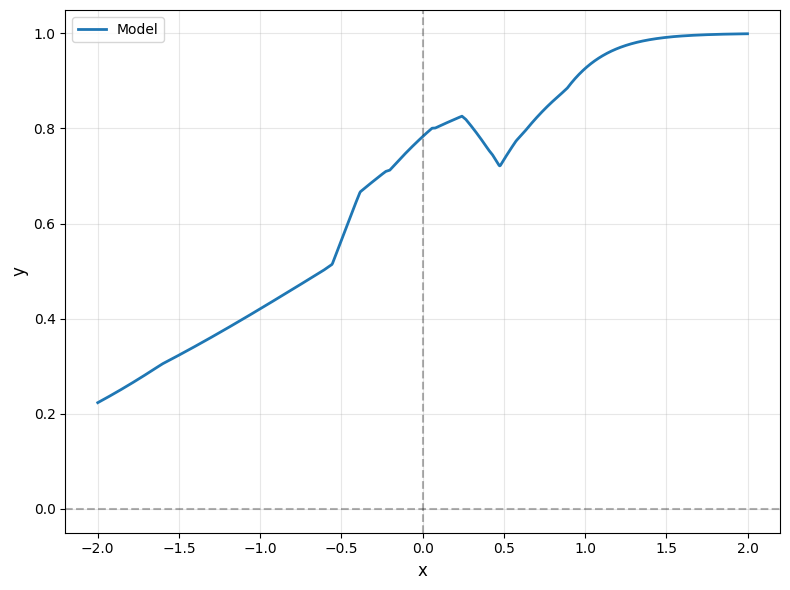

<Axes: xlabel='x', ylabel='y'>

In [129]:
linear_1 = Linear(input_size=1, output_size=32)
activation_1 = ReLU()
linear_2 = Linear(input_size=32, output_size=1)
activation_2 = Sigmoid()
plot(linear_1, activation_1, linear_2, activation_2, x_min=-2, x_max=2)

## Optimizer

In [130]:
mse = MSELoss()
learning_rate = 0.07
num_steps = 5

## Training

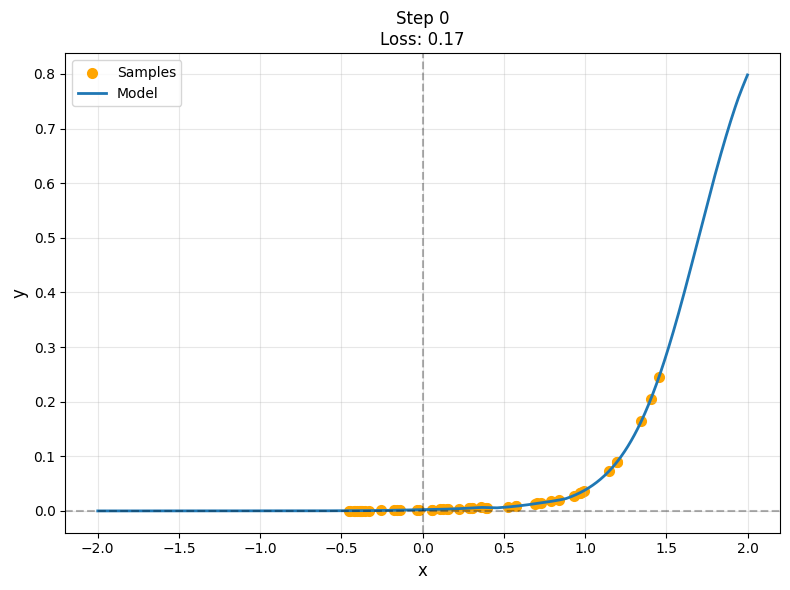

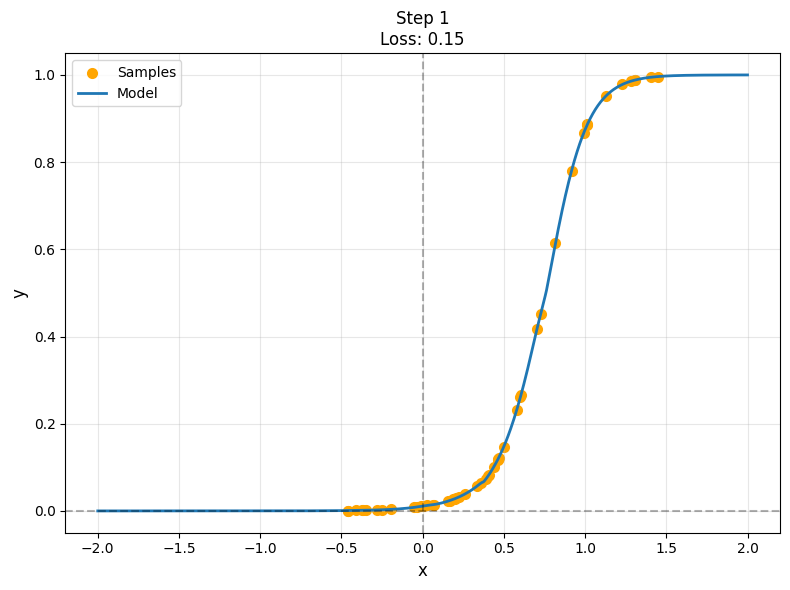

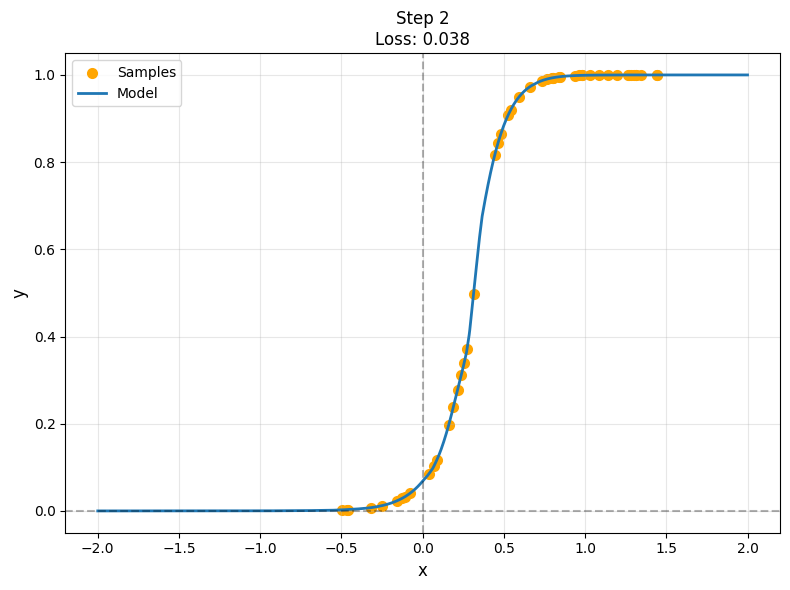

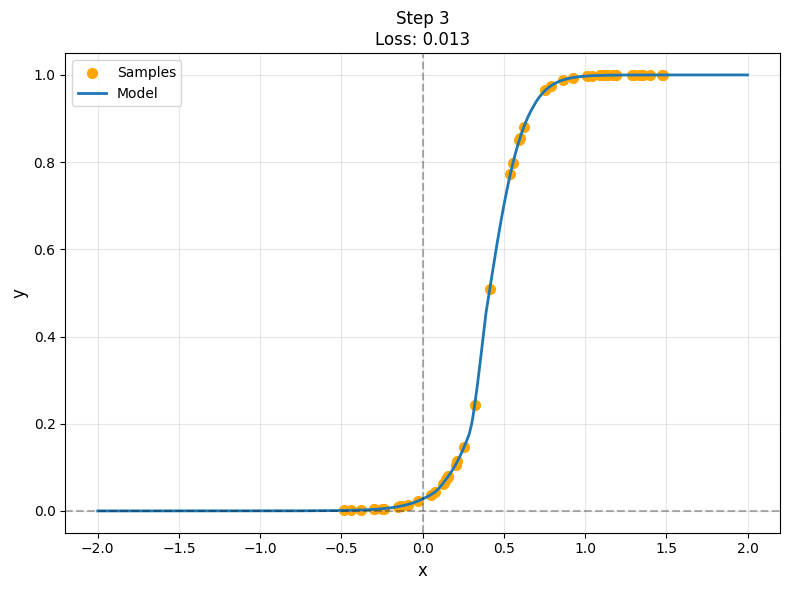

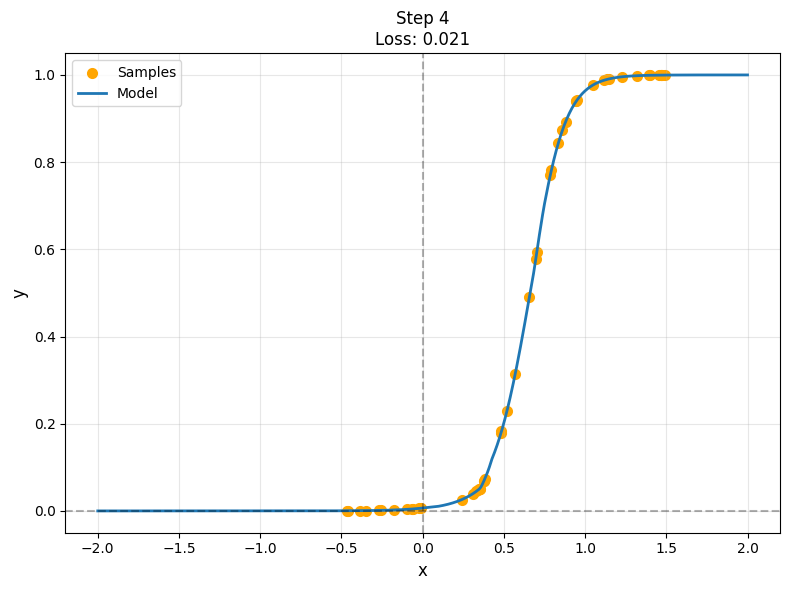

In [131]:
for step in range(0, num_steps):
    x = batches_x[step]
    y = batches_y[step]

    # Forward propagation
    z = linear_1(x)
    z = activation_1(z)
    z = linear_2(z)
    z = activation_2(z)

    # Loss computation
    loss = mse(z, y).mean()

    # Back propagation
    grad_loss = mse.backward()
    grad_act_2 = activation_2.backward(grad_loss)
    grad_w_2, grad_b_2, grad_x_2 = linear_2.backward(grad_act_2)
    grad_act_1 = activation_1.backward(grad_x_2)
    grad_w_1, grad_b_1, grad_x_1 = linear_1.backward(grad_act_1)

    # Parameter update
    linear_2.w = linear_2.w - learning_rate * grad_w_2
    linear_2.b = linear_2.b - learning_rate * grad_b_2
    linear_1.w = linear_1.w - learning_rate * grad_w_1
    linear_1.b = linear_1.b - learning_rate * grad_b_1

    plot(
        linear_1,
        activation_1,
        linear_2,
        activation_2,
        x_min=-2,
        x_max=2,
        samples=x,
        title=f"Step {step}\nLoss: {loss:.2}",
    )